# Case 3 Demo: ADR Forward Solver and PINO-Based Parameter Identification

This notebook presents a compact demonstration of the case-3 workflow on a steady advection-diffusion-reaction channel problem for `A + B -> C`.

The workflow is organized as follows:

1. solve the forward ADR problem
2. use the resulting field as a synthetic reference
3. build a compact forward surrogate
4. identify the kinetic parameter `k` from the reference `c_A` field
5. export a small set of paper-style figures

All generated files are written to the relative folder `github_demo_outputs/`.

## Requirements

`numpy`, `matplotlib`, and `torch`

The default settings are chosen to keep the demo compact and easy to reproduce in a notebook setting. If needed, the training and inverse settings can be adjusted in `DemoConfig`.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ImportError as exc:
    raise ImportError(
        "This notebook requires PyTorch. Install torch before running the demo."
    ) from exc


SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float32)

OUTPUT_DIR = Path("github_demo_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Outputs will be written to: {OUTPUT_DIR}")

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": 13,
        "axes.titlesize": 13,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "legend.fontsize": 11,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    }
)


Using device: cpu
Outputs will be written to: github_demo_outputs


Forward solver finished in 6.86 s | steps=5450 | dt=6.416e+00


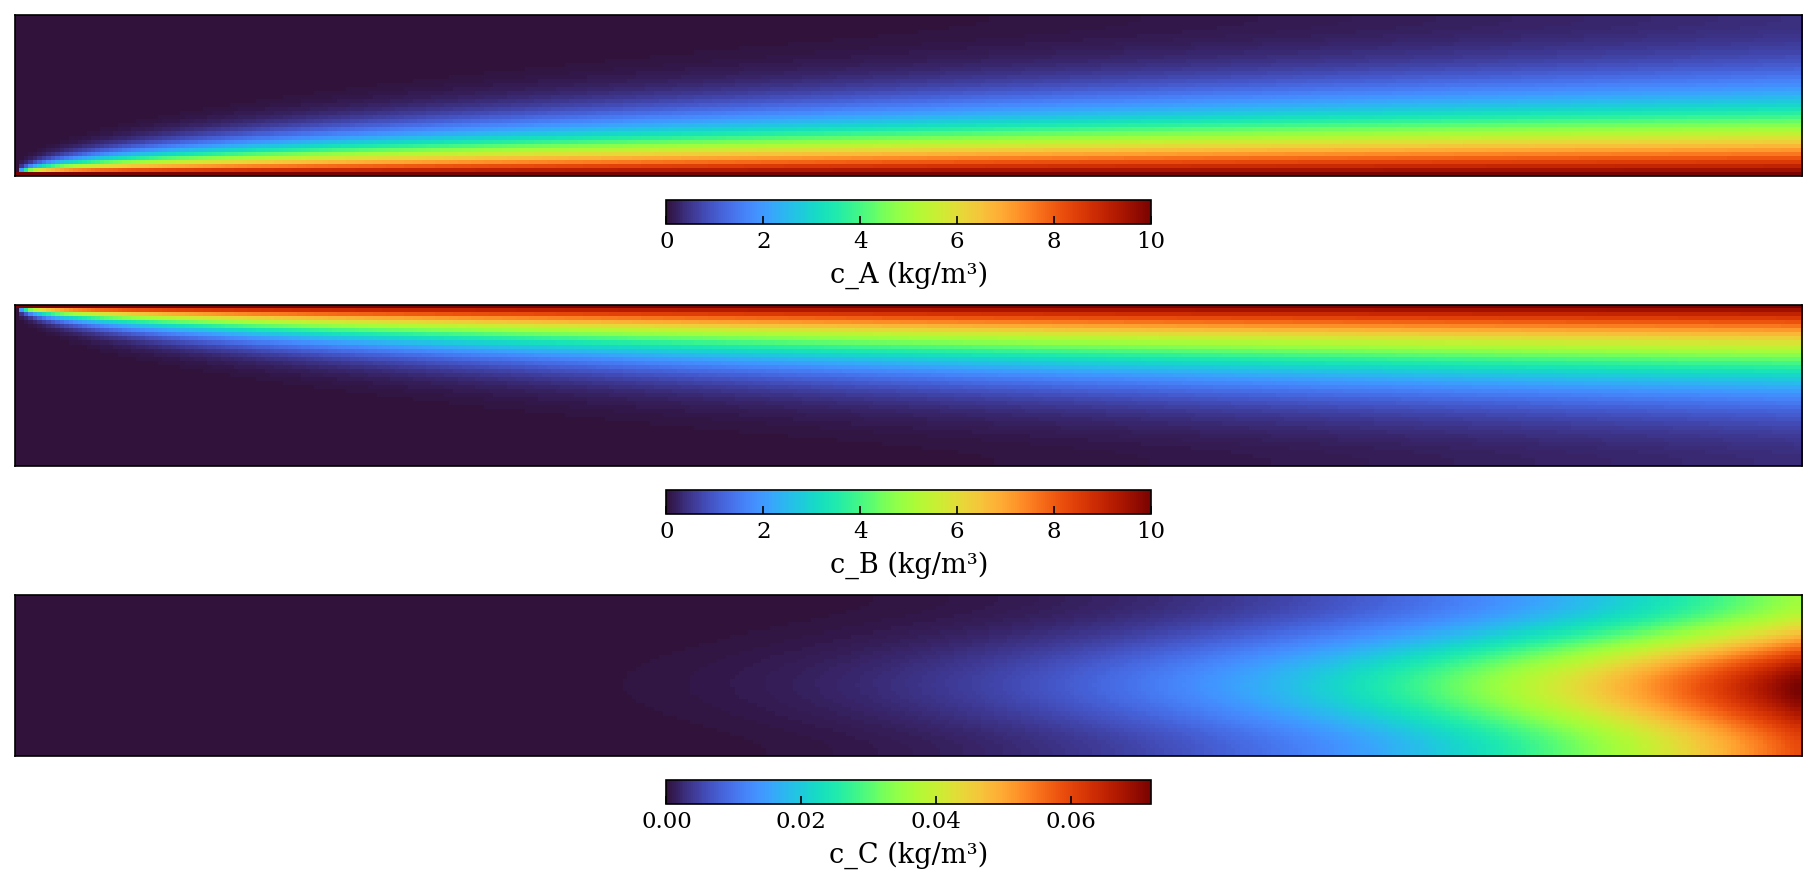

Saved forward fields to: github_demo_outputs/adr_channel_demo.pkl
Saved forward figure to: github_demo_outputs/adr_channel_demo.svg


In [2]:
@dataclass
class DemoConfig:
    # Geometry and mesh
    L: float = 1.6
    H: float = 0.16
    Nx: int = 400
    Ny: int = 40

    # Flow and transport
    u: float = 5e-5
    D: float = 7.407e-8

    # Reaction
    k: float = 1.2e-6
    mA: float = 1.3
    mB: float = 1.1

    # Boundary values
    A_wall: float = 10.0
    B_wall: float = 10.0
    C_wall: float = 0.0

    # Forward solver controls
    max_steps: int = 50000
    check_every: int = 50
    tol: float = 5e-5
    consec_needed: int = 3
    cfl_adv: float = 0.4
    cfl_diff: float = 0.15

    # Demo-sized learning settings
    train_epochs: int = 600
    inverse_steps: int = 150
    train_lr: float = 5e-4
    inverse_lr: float = 2e-2
    inverse_patience: int = 120
    inverse_min_delta: float = 1e-4
    inverse_metric_alpha: float = 1.0
    inverse_metric_beta: float = 1.0
    reuse_forward_checkpoint: bool = True


def run_forward_solver(cfg: DemoConfig):
    start_time = time.time()

    L, H, Nx, Ny = cfg.L, cfg.H, cfg.Nx, cfg.Ny
    dx, dy = L / (Nx - 1), H / (Ny - 1)
    x = np.linspace(0.0, L, Nx)
    y = np.linspace(0.0, H, Ny)

    A = np.zeros((Ny, Nx))
    B = np.zeros((Ny, Nx))
    C = np.zeros((Ny, Nx))

    def adv_x_2up(phi):
        der = np.zeros_like(phi)
        der[:, 2:] = (3 * phi[:, 2:] - 4 * phi[:, 1:-1] + phi[:, :-2]) / (2 * dx)
        der[:, 1] = (phi[:, 1] - phi[:, 0]) / dx
        der[:, 0] = der[:, 1]
        return der

    def lap(phi):
        out = np.zeros_like(phi)
        out[1:-1, 1:-1] = (
            (phi[1:-1, 2:] - 2 * phi[1:-1, 1:-1] + phi[1:-1, :-2]) / dx**2
            + (phi[2:, 1:-1] - 2 * phi[1:-1, 1:-1] + phi[:-2, 1:-1]) / dy**2
        )
        return out

    def apply_bcs():
        A[:, 0] = 0.0
        B[:, 0] = 0.0
        C[:, 0] = 0.0

        A[:, -1] = A[:, -2]
        B[:, -1] = B[:, -2]
        C[:, -1] = C[:, -2]

        A[0, :] = cfg.A_wall
        B[0, :] = B[1, :]
        C[0, :] = C[1, :]

        B[-1, :] = cfg.B_wall
        A[-1, :] = A[-2, :]
        C[-1, :] = C[-2, :]

    dt_adv = cfg.cfl_adv * dx / max(cfg.u, 1e-16)
    dt_diff = cfg.cfl_diff * min(dx, dy) ** 2 / (cfg.D + 1e-16)
    dt = 0.2 * min(dt_adv, dt_diff)

    apply_bcs()
    consec_ok = 0

    for step in range(1, cfg.max_steps + 1):
        A0, B0, C0 = A.copy(), B.copy(), C.copy()

        v = cfg.k * np.power(np.maximum(A, 0.0), cfg.mA) * np.power(np.maximum(B, 0.0), cfg.mB)
        A += dt * (-cfg.u * adv_x_2up(A) + cfg.D * lap(A) - v)
        B += dt * (-cfg.u * adv_x_2up(B) + cfg.D * lap(B) - v)
        C += dt * (-cfg.u * adv_x_2up(C) + cfg.D * lap(C) + v)

        A = np.clip(A, 0.0, None)
        B = np.clip(B, 0.0, None)
        C = np.clip(C, 0.0, None)
        apply_bcs()

        if step % cfg.check_every == 0:
            def rel_change(new, old):
                denom = np.maximum(np.abs(old), 1e-10)
                return float(np.max(np.abs(new - old) / denom))

            residual = max(rel_change(A, A0), rel_change(B, B0), rel_change(C, C0))
            consec_ok = consec_ok + 1 if residual < cfg.tol else 0
            if consec_ok >= cfg.consec_needed:
                break

    runtime = time.time() - start_time
    return {
        "A": A,
        "B": B,
        "C": C,
        "x": x,
        "y": y,
        "cfg": cfg,
        "dt": dt,
        "steps": step,
        "runtime": runtime,
    }


cfg = DemoConfig()
forward = run_forward_solver(cfg)
A, B, C = forward["A"], forward["B"], forward["C"]

print(
    f"Forward solver finished in {forward['runtime']:.2f} s | "
    f"steps={forward['steps']} | dt={forward['dt']:.3e}"
)

extent = [0.0, cfg.L, 0.0, cfg.H]
fig, axes = plt.subplots(3, 1, figsize=(12, 5.8), constrained_layout=True)
for ax, field, label, vmax in [
    (axes[0], A, "c_A (kg/m³)", cfg.A_wall),
    (axes[1], B, "c_B (kg/m³)", cfg.B_wall),
    (axes[2], C, "c_C (kg/m³)", 7.192e-2),
]:
    im = ax.imshow(field, origin="lower", extent=extent, aspect="auto", cmap="turbo", vmin=0.0, vmax=vmax)
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.12).set_label(label)
    ax.set_xticks([])
    ax.set_yticks([])

forward_fig = OUTPUT_DIR / "adr_channel_demo.svg"
fig.savefig(forward_fig, format="svg", bbox_inches="tight")
plt.show()

forward_pkl = OUTPUT_DIR / "adr_channel_demo.pkl"
with forward_pkl.open("wb") as f:
    pickle.dump(
        {
            "A": A,
            "B": B,
            "C": C,
            "x": forward["x"],
            "y": forward["y"],
            "cfg": cfg,
            "steps": forward["steps"],
            "dt": forward["dt"],
        },
        f,
    )

print(f"Saved forward fields to: {forward_pkl}")
print(f"Saved forward figure to: {forward_fig}")


In [3]:
with (OUTPUT_DIR / "adr_channel_demo.pkl").open("rb") as f:
    data = pickle.load(f)

A_ref, B_ref, C_ref = data["A"], data["B"], data["C"]
xv, yv = data["x"], data["y"]
cfg = data["cfg"]

Ny, Nx = A_ref.shape
x = np.broadcast_to(xv[None, :], (Ny, Nx))
y = np.broadcast_to(yv[:, None], (Ny, Nx))

k_scale = 1e-6
k_s_true = cfg.k / k_scale

X_single = np.stack(
    [
        np.full_like(A_ref, k_s_true, dtype=np.float32),
        np.full_like(A_ref, cfg.mA, dtype=np.float32),
        np.full_like(A_ref, cfg.mB, dtype=np.float32),
        (x / cfg.L).astype(np.float32),
        (y / cfg.H).astype(np.float32),
    ],
    axis=0,
)[None, ...]

Y_single = np.stack([A_ref, B_ref, C_ref], axis=0)[None, ...].astype(np.float32)
Y_mean = Y_single.mean(axis=(0, 2, 3), keepdims=True)
Y_std = Y_single.std(axis=(0, 2, 3), keepdims=True) + 1e-8


def to_torch(x):
    return torch.tensor(x, dtype=torch.float32, device=device)


def denorm_torch(y_norm):
    return y_norm * to_torch(Y_std) + to_torch(Y_mean)


Xtr_t = to_torch(X_single)
Ytr_t = to_torch((Y_single - Y_mean) / Y_std)
A_mean, A_std = float(Y_mean[0, 0, 0, 0]), float(Y_std[0, 0, 0, 0])
Aref_n_t = to_torch(((A_ref - A_mean) / A_std)[None, None, ...])


class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_x=24, modes_y=12):
        super().__init__()
        self.modes_x = modes_x
        self.modes_y = modes_y
        scale = 1.0 / (in_channels * out_channels)
        self.weight = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes_y, modes_x, dtype=torch.cfloat)
        )

    def forward(self, x):
        batch_size, _, ny, nx = x.shape
        x_ft = torch.fft.rfft2(x, norm="ortho")
        ky = min(self.modes_y, ny)
        kx = min(self.modes_x, nx // 2 + 1)
        out_ft = torch.zeros(
            batch_size,
            self.weight.shape[1],
            ny,
            nx // 2 + 1,
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, :ky, :kx] = torch.einsum(
            "bcpq,copq->bopq", x_ft[:, :, :ky, :kx], self.weight[:, :, :ky, :kx]
        )
        return torch.fft.irfft2(out_ft, s=(ny, nx), norm="ortho").real


class FNOBlock(nn.Module):
    def __init__(self, width, modes_x=24, modes_y=12):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes_x, modes_y)
        self.w = nn.Conv2d(width, width, 1)
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.spectral(x) + self.w(x))


class FNO2D(nn.Module):
    def __init__(self, in_channels=5, out_channels=3, width=48, depth=6, modes_x=24, modes_y=12):
        super().__init__()
        self.fc0 = nn.Conv2d(in_channels, width, 1)
        self.blocks = nn.ModuleList([FNOBlock(width, modes_x, modes_y) for _ in range(depth)])
        self.fc1 = nn.Conv2d(width, width, 1)
        self.fc2 = nn.Conv2d(width, out_channels, 1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.fc0(x)
        for block in self.blocks:
            x = block(x)
        x = self.act(self.fc1(x))
        return self.fc2(x)


dx = cfg.L / (cfg.Nx - 1)
dy = cfg.H / (cfg.Ny - 1)
u = to_torch(cfg.u)
D = to_torch(cfg.D)
Awall = to_torch(cfg.A_wall)
Bwall = to_torch(cfg.B_wall)
mA_t = to_torch(cfg.mA)
mB_t = to_torch(cfg.mB)
k_s_t = to_torch(k_s_true)


def ddx_upwind2(phi):
    der = torch.zeros_like(phi)
    der[:, :, 2:] = (3 * phi[:, :, 2:] - 4 * phi[:, :, 1:-1] + phi[:, :, :-2]) / (2 * dx)
    der[:, :, 1] = (phi[:, :, 1] - phi[:, :, 0]) / dx
    der[:, :, 0] = der[:, :, 1]
    return der


def laplace_center2(phi):
    out = torch.zeros_like(phi)
    out[:, 1:-1, 1:-1] = (
        (phi[:, 1:-1, 2:] - 2 * phi[:, 1:-1, 1:-1] + phi[:, 1:-1, :-2]) / (dx * dx)
        + (phi[:, 2:, 1:-1] - 2 * phi[:, 1:-1, 1:-1] + phi[:, :-2, 1:-1]) / (dy * dy)
    )
    return out


def pde_residual_loss(Y_phys, k_s, mA, mB):
    k = k_s * k_scale
    A = Y_phys[:, 0]
    B = Y_phys[:, 1]
    C = Y_phys[:, 2]
    reaction = k * (A.clamp_min(0.0) ** mA) * (B.clamp_min(0.0) ** mB)
    RA = -u * ddx_upwind2(A) + D * laplace_center2(A) - reaction
    RB = -u * ddx_upwind2(B) + D * laplace_center2(B) - reaction
    RC = -u * ddx_upwind2(C) + D * laplace_center2(C) + reaction
    return (
        (RA[:, 1:-1, 1:-1] ** 2).mean()
        + (RB[:, 1:-1, 1:-1] ** 2).mean()
        + (RC[:, 1:-1, 1:-1] ** 2).mean()
    )


def bc_loss(Y_phys):
    A = Y_phys[:, 0]
    B = Y_phys[:, 1]
    C = Y_phys[:, 2]
    loss_in = (A[:, :, 0] ** 2).mean() + (B[:, :, 0] ** 2).mean() + (C[:, :, 0] ** 2).mean()
    loss_out = (
        ((A[:, :, -1] - A[:, :, -2]) ** 2).mean()
        + ((B[:, :, -1] - B[:, :, -2]) ** 2).mean()
        + ((C[:, :, -1] - C[:, :, -2]) ** 2).mean()
    )
    loss_bottom = (
        ((A[:, 0, :] - Awall) ** 2).mean()
        + ((B[:, 1, :] - B[:, 0, :]) ** 2).mean()
        + ((C[:, 1, :] - C[:, 0, :]) ** 2).mean()
    )
    loss_top = (
        ((B[:, -1, :] - Bwall) ** 2).mean()
        + ((A[:, -1, :] - A[:, -2, :]) ** 2).mean()
        + ((C[:, -1, :] - C[:, -2, :]) ** 2).mean()
    )
    return loss_in + loss_out + loss_bottom + loss_top


model = FNO2D().to(device)
optimizer = optim.Adam(model.parameters(), lr=cfg.train_lr)
forward_ckpt = OUTPUT_DIR / "forward_surrogate_state_dict_demo.pt"

lambda_data = 25.0
lambda_pde = 0.5e-2
lambda_bc = 1e-3

history = []
c_out_ref = float(C_ref[:, -1].mean())
if cfg.reuse_forward_checkpoint and forward_ckpt.exists():
    state_dict = torch.load(forward_ckpt, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Loaded forward surrogate weights from: {forward_ckpt}")
else:
    print(f"Training forward surrogate for {cfg.train_epochs} epochs (data loss only)...")
    start_train = time.time()
    for epoch in range(1, cfg.train_epochs + 1):
        optimizer.zero_grad()
        pred_norm = model(Xtr_t)
        loss_data = torch.mean((pred_norm - Ytr_t) ** 2)
        loss_total = loss_data
        loss_total.backward()
        optimizer.step()
        if epoch % 50 == 0 or epoch == 1:
            print(
                f"[Train {epoch:04d}/{cfg.train_epochs}] "
                f"data={loss_data:.3e} total={loss_total:.3e}"
            )

    print(f"Training finished in {time.time() - start_train:.2f} s")
    torch.save(model.state_dict(), forward_ckpt)
    print(f"Saved forward surrogate weights to: {forward_ckpt}")

for p in model.parameters():
    p.requires_grad = False
model.eval()

logs_k = nn.Parameter(torch.tensor(np.log10(0.1e-6 / k_scale), device=device))
inverse_optimizer = optim.Adam([logs_k], lr=cfg.inverse_lr)
best_metric = float("inf")
best_rel_c_out_error = float("inf")
best_field_loss = float("inf")
best_step = 0
steps_without_improvement = 0


def build_input(logs_value):
    logs_clamped = torch.clamp(logs_value, -2.0, 2.0)
    k_s = torch.pow(10.0, logs_clamped)
    K = k_s.expand(Ny, Nx)
    MA = mA_t.expand(Ny, Nx)
    MB = mB_t.expand(Ny, Nx)
    x_ch = to_torch((x / cfg.L).astype(np.float32))
    y_ch = to_torch((y / cfg.H).astype(np.float32))
    Xin = torch.stack([K, MA, MB, x_ch, y_ch], dim=0).unsqueeze(0)
    return Xin, k_s


def evaluate_inverse_state(logs_value):
    Xin_eval, k_s_eval = build_input(logs_value)
    pred_norm_eval = model(Xin_eval.float())
    Y_phys_eval = denorm_torch(pred_norm_eval)
    loss_field_eval = torch.mean((pred_norm_eval[:, 0:1] - Aref_n_t) ** 2)
    loss_pde_eval = pde_residual_loss(Y_phys_eval, k_s_eval, mA_t, mB_t)
    loss_bc_eval = bc_loss(Y_phys_eval)
    k_s_val = float(torch.pow(10.0, logs_value.clamp(-2.0, 2.0)).cpu())
    k_val = k_s_val * k_scale
    c_out_pred = float(Y_phys_eval[:, 2, :, -1].mean().detach().cpu())
    rel_c_out_error = abs(c_out_pred - c_out_ref) / (abs(c_out_ref) + 1e-8)
    return (
        pred_norm_eval,
        Y_phys_eval,
        loss_field_eval,
        loss_pde_eval,
        loss_bc_eval,
        k_val,
        c_out_pred,
        rel_c_out_error,
    )


print(f"Running backward parameter identification for {cfg.inverse_steps} steps...")
start_inverse = time.time()
for step in range(1, cfg.inverse_steps + 1):
    inverse_optimizer.zero_grad()
    pred_norm, Y_phys, loss_field, loss_pde, loss_bc, _, _, _ = evaluate_inverse_state(logs_k)
    loss_total = lambda_data * loss_field + lambda_pde * loss_pde + lambda_bc * loss_bc
    loss_total.backward()
    inverse_optimizer.step()

    with torch.no_grad():
        pred_norm_eval, Y_phys_eval, loss_field_eval, loss_pde_eval, loss_bc_eval, k_val, c_out_pred, rel_c_out_error = evaluate_inverse_state(logs_k)
        field_loss_value = float(loss_field_eval.detach().cpu())
        loss_pde_value = float(loss_pde_eval.detach().cpu())
        loss_bc_value = float(loss_bc_eval.detach().cpu())
        loss_total_value = float(
            (lambda_data * loss_field_eval + lambda_pde * loss_pde_eval + lambda_bc * loss_bc_eval).detach().cpu()
        )
        combined_metric = (
            cfg.inverse_metric_alpha * field_loss_value
            + cfg.inverse_metric_beta * rel_c_out_error
        )

        if combined_metric < best_metric - cfg.inverse_min_delta:
            best_metric = combined_metric
            best_rel_c_out_error = rel_c_out_error
            best_field_loss = field_loss_value
            best_step = step
            steps_without_improvement = 0
        else:
            steps_without_improvement += 1

    history.append(
        {
            "loss": loss_total_value,
            "field_loss": field_loss_value,
            "k": k_val,
            "c_out": c_out_pred,
            "rel_c_out_error": rel_c_out_error,
            "combined_metric": combined_metric,
        }
    )

    if step % 25 == 0 or step == 1:
        print(
            f"[Inverse {step:04d}/{cfg.inverse_steps}] "
            f"field={loss_field_eval:.3e} pde={loss_pde_eval:.3e} bc={loss_bc_eval:.3e} "
            f"total={loss_total_value:.3e} k={k_val:.3e} rel_c_out={rel_c_out_error:.3e} metric={combined_metric:.3e}"
        )

    if steps_without_improvement >= cfg.inverse_patience:
        print(
            f"Early stopping inverse stage at step {step}: "
            f"best metric={best_metric:.3e} at step {best_step}"
        )
        break

print(f"Inverse stage finished in {time.time() - start_inverse:.2f} s")

with torch.no_grad():
    _, Y_pred_t, _, _, _, k_final, c_out_final, rel_c_out_final = evaluate_inverse_state(logs_k.detach())
    Y_pred = Y_pred_t.detach().cpu().numpy()

result = {
    "hist": history,
    "k_true": float(cfg.k),
    "k_id": k_final,
    "c_out_ref": c_out_ref,
    "c_out_id": c_out_final,
    "rel_c_out_final": rel_c_out_final,
    "best_metric": best_metric,
    "best_rel_c_out_error": best_rel_c_out_error,
    "best_field_loss": best_field_loss,
    "best_step": best_step,
    "mA_fixed": float(cfg.mA),
    "mB_fixed": float(cfg.mB),
    "Y_single": Y_single,
    "Y_pred": Y_pred,
    "cfg": cfg,
    "forward_checkpoint": str(forward_ckpt),
    "note": "GitHub demo: forward model trained with data loss only; backward stage identifies k from the reference c_A field",
}

result_pkl = OUTPUT_DIR / "adr_pino_result_k_only_demo.pkl"
with result_pkl.open("wb") as f:
    pickle.dump(result, f)

print(f"Saved inverse result to: {result_pkl}")
print(f"Recovered k = {k_final:.3e} | true k = {cfg.k:.3e}")
print(
    f"Best metric = {best_metric:.3e} at step {best_step} "
    f"(field={best_field_loss:.3e}, rel_c_out={best_rel_c_out_error:.3e})"
)


/scratch/e1518147/.codex-tmp/ipykernel_2212641/2844765125.py:180: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(forward_ckpt, map_location=device)


Loaded forward surrogate weights from: github_demo_outputs/forward_surrogate_state_dict_demo.pt
Running backward parameter identification for 150 steps...


[Inverse 0001/150] field=5.948e-03 pde=3.541e-07 bc=5.300e+00 total=1.540e-01 k=1.047e-07 rel_c_out=5.543e-02 metric=6.138e-02


[Inverse 0025/150] field=3.411e-03 pde=3.166e-07 bc=5.148e+00 total=9.041e-02 k=3.358e-07 rel_c_out=4.257e-02 metric=4.598e-02


[Inverse 0050/150] field=2.730e-05 pde=2.568e-07 bc=5.041e+00 total=5.724e-03 k=1.210e-06 rel_c_out=4.630e-03 metric=4.657e-03


[Inverse 0075/150] field=3.111e-05 pde=2.564e-07 bc=5.038e+00 total=5.816e-03 k=1.165e-06 rel_c_out=6.140e-03 metric=6.171e-03


[Inverse 0100/150] field=2.806e-05 pde=2.569e-07 bc=5.042e+00 total=5.743e-03 k=1.218e-06 rel_c_out=4.362e-03 metric=4.390e-03


[Inverse 0125/150] field=2.715e-05 pde=2.566e-07 bc=5.040e+00 total=5.719e-03 k=1.193e-06 rel_c_out=5.205e-03 metric=5.232e-03


[Inverse 0150/150] field=2.697e-05 pde=2.567e-07 bc=5.040e+00 total=5.715e-03 k=1.201e-06 rel_c_out=4.939e-03 metric=4.966e-03
Inverse stage finished in 42.70 s
Saved inverse result to: github_demo_outputs/adr_pino_result_k_only_demo.pkl
Recovered k = 1.201e-06 | true k = 1.200e-06
Best metric = 2.796e-04 at step 63 (field=1.129e-04, rel_c_out=1.667e-04)


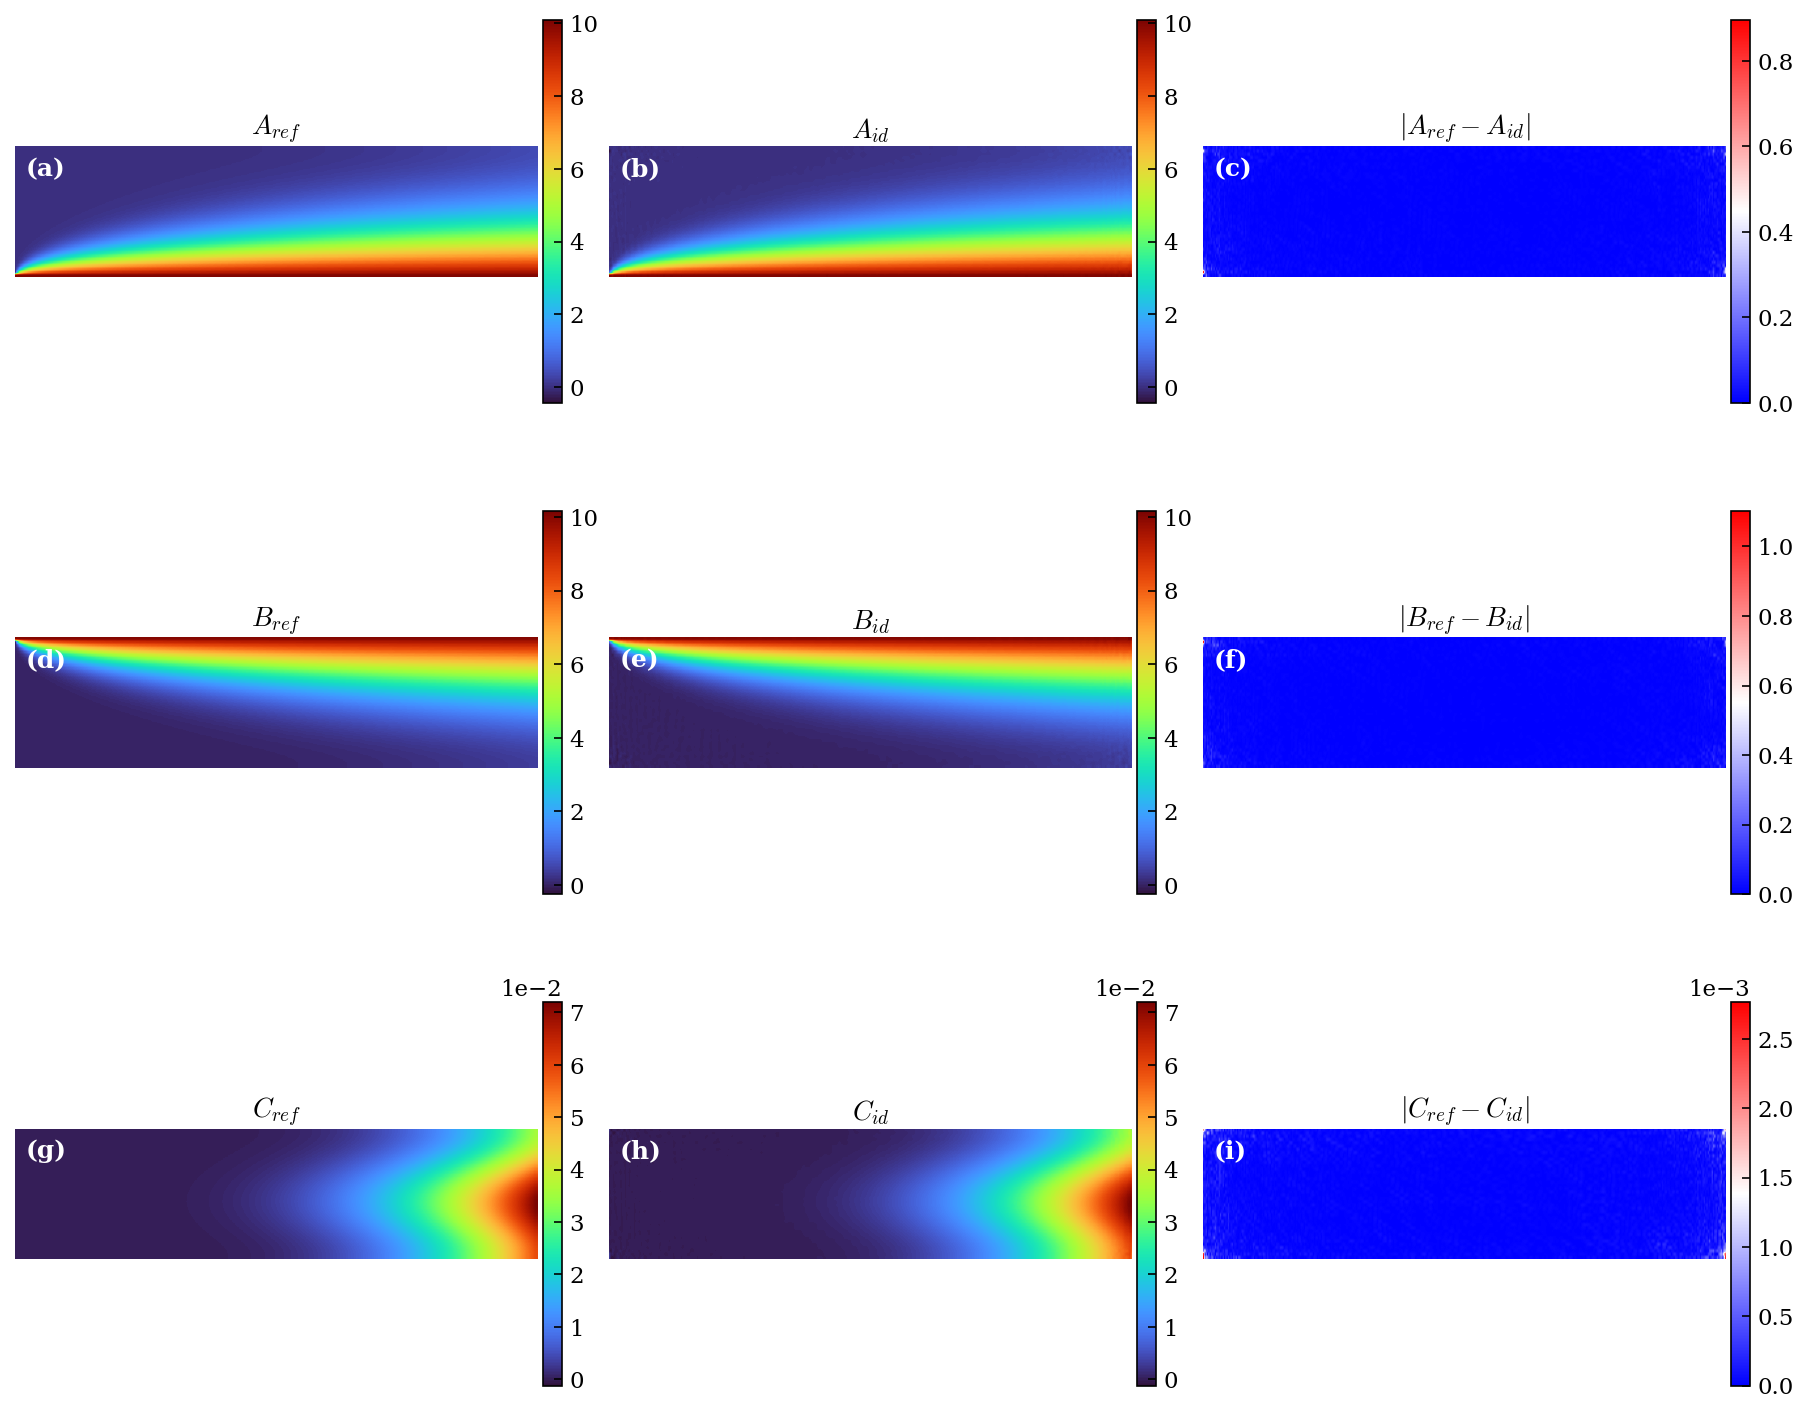

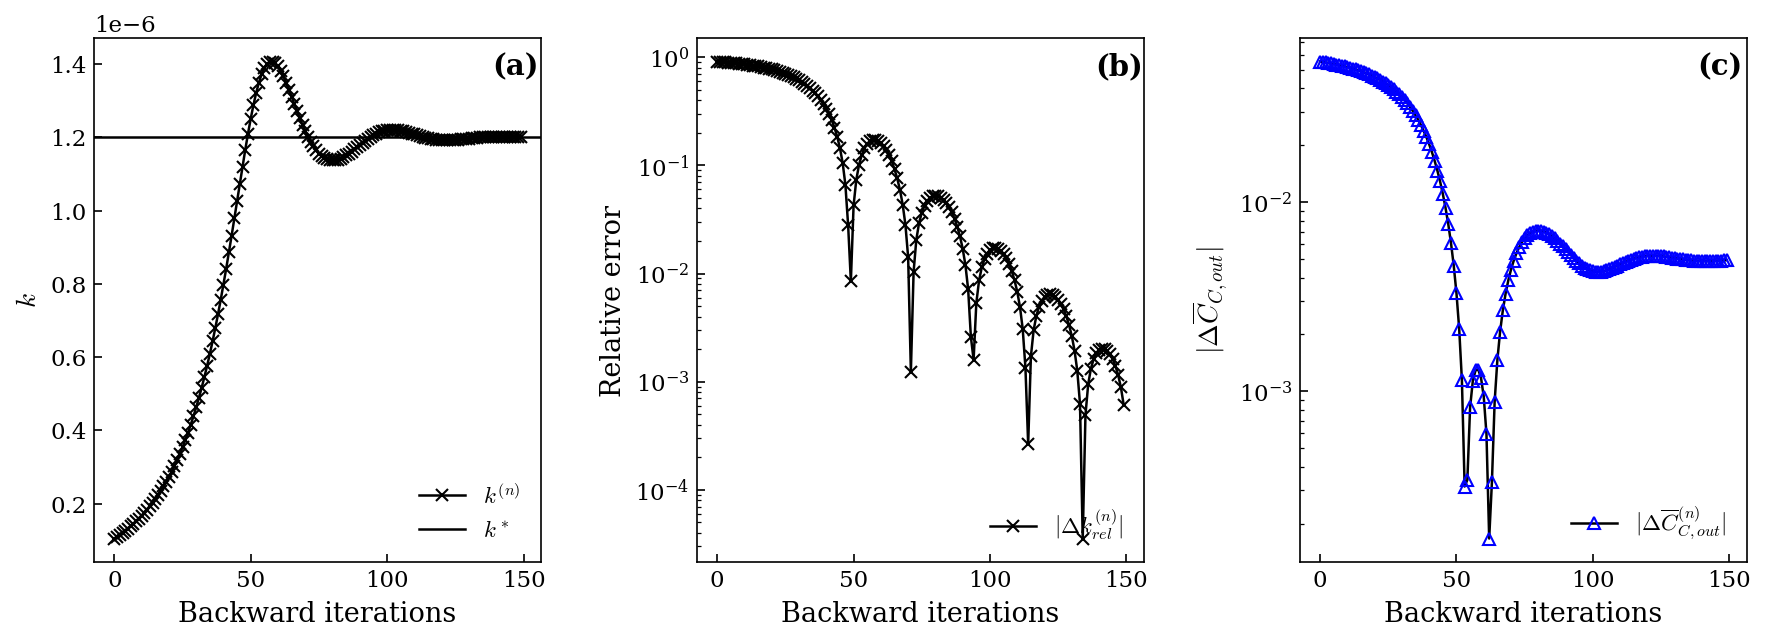

Field comparison figure: github_demo_outputs/field_comparison_demo.svg
Convergence figure: github_demo_outputs/triple_panel_identification_demo.svg
Final identified k: 1.201e-06
True k: 1.200e-06
Reference outlet average C: 5.766e-02
Identified outlet average C: 5.738e-02
Best metric observed: 2.796e-04 at step 63 (field=1.129e-04, rel_c_out=1.667e-04)


In [4]:
with (OUTPUT_DIR / "adr_pino_result_k_only_demo.pkl").open("rb") as f:
    result = pickle.load(f)

hist = result["hist"]
k_true = float(result["k_true"])
k_id = float(result["k_id"])
c_out_ref = float(result["c_out_ref"])
c_out_id = float(result["c_out_id"])
best_metric = float(result["best_metric"])
best_rel_c_out_error = float(result["best_rel_c_out_error"])
best_field_loss = float(result["best_field_loss"])
best_step = int(result["best_step"])
Y_single = np.array(result["Y_single"])
Y_pred = np.array(result["Y_pred"])

A_ref, B_ref, C_ref = Y_single[0]
if Y_pred.ndim == 4:
    Y_pred = Y_pred[0]
A_id, B_id, C_id = Y_pred

fig, axs = plt.subplots(3, 3, figsize=(12, 10))
titles = [
    [r"$A_{ref}$", r"$A_{id}$", r"$|A_{ref} - A_{id}|$"],
    [r"$B_{ref}$", r"$B_{id}$", r"$|B_{ref} - B_{id}|$"],
    [r"$C_{ref}$", r"$C_{id}$", r"$|C_{ref} - C_{id}|$"],
]
fields = [
    [A_ref, A_id, np.abs(A_ref - A_id)],
    [B_ref, B_id, np.abs(B_ref - B_id)],
    [C_ref, C_id, np.abs(C_ref - C_id)],
]

pair_limits = [
    (float(min(A_ref.min(), A_id.min())), float(max(A_ref.max(), A_id.max()))),
    (float(min(B_ref.min(), B_id.min())), float(max(B_ref.max(), B_id.max()))),
    (float(min(C_ref.min(), C_id.min())), float(max(C_ref.max(), C_id.max()))),
]
err_limits = [
    (0.0, float(np.abs(A_ref - A_id).max())),
    (0.0, float(np.abs(B_ref - B_id).max())),
    (0.0, float(np.abs(C_ref - C_id).max())),
]

for i in range(3):
    for j in range(3):
        if j < 2:
            vmin, vmax = pair_limits[i]
            cmap = "turbo"
        else:
            vmin, vmax = err_limits[i]
            cmap = "bwr"
        im = axs[i, j].imshow(
            fields[i][j],
            origin="lower",
            cmap=cmap,
            aspect="auto",
            vmin=vmin,
            vmax=vmax,
        )
        axs[i, j].set_box_aspect(0.25)
        axs[i, j].set_title(titles[i][j], pad=4)
        axs[i, j].axis("off")
        axs[i, j].text(
            0.02,
            0.92,
            f"({chr(97 + 3 * i + j)})",
            transform=axs[i, j].transAxes,
            fontsize=12,
            fontweight="bold",
            color="white",
            ha="left",
            va="top",
        )
        cbar = plt.colorbar(im, ax=axs[i, j], fraction=0.035, pad=0.01)
        cbar.formatter.set_powerlimits((-2, 2))
        cbar.ax.yaxis.get_offset_text().set(size=11)
        cbar.update_ticks()

plt.tight_layout(pad=0.5)
field_fig = OUTPUT_DIR / "field_comparison_demo.svg"
plt.savefig(field_fig, format="svg", bbox_inches="tight")
plt.show()

k_series = np.array([row["k"] for row in hist], dtype=float)
rel_k_series = np.abs((k_true - k_series) / k_true)
delta_c_series = np.array([row["rel_c_out_error"] for row in hist], dtype=float)
iterations = np.arange(len(k_series))

fig, axs = plt.subplots(1, 3, figsize=(12, 4.5))

axs[0].plot(iterations, k_series, "k-x", lw=1.2, label=r"$k^{(n)}$")
axs[0].axhline(k_true, color="k", lw=1.2, linestyle="-", label=r"$k^*$")
axs[0].set_xlabel("Backward iterations")
axs[0].set_ylabel(r"$k$")
axs[0].legend(frameon=False, loc="lower right")
axs[0].text(0.89, 0.93, "(a)", transform=axs[0].transAxes, fontsize=14, fontweight="bold")

axs[1].semilogy(iterations, rel_k_series, "k-x", lw=1.2, label=r"$|\Delta k_{rel}^{(n)}|$")
axs[1].set_xlabel("Backward iterations")
axs[1].set_ylabel("Relative error")
axs[1].legend(frameon=False, loc="lower right")
axs[1].text(0.89, 0.93, "(b)", transform=axs[1].transAxes, fontsize=14, fontweight="bold")

axs[2].semilogy(
    iterations,
    delta_c_series,
    color="k",
    marker="^",
    mfc="none",
    mec="b",
    ms=6,
    lw=1.2,
    label=r"$|\Delta \overline{C}_{C,out}^{(n)}|$",
)
axs[2].set_xlabel("Backward iterations")
axs[2].set_ylabel(r"$|\Delta \overline{C}_{C,out}|$")
axs[2].legend(frameon=False, loc="lower right")
axs[2].text(0.89, 0.93, "(c)", transform=axs[2].transAxes, fontsize=14, fontweight="bold")

plt.tight_layout(pad=1.5, w_pad=2)
conv_fig = OUTPUT_DIR / "triple_panel_identification_demo.svg"
plt.savefig(conv_fig, format="svg", bbox_inches="tight")
plt.show()

print(f"Field comparison figure: {field_fig}")
print(f"Convergence figure: {conv_fig}")
print(f"Final identified k: {k_id:.3e}")
print(f"True k: {k_true:.3e}")
print(f"Reference outlet average C: {c_out_ref:.3e}")
print(f"Identified outlet average C: {c_out_id:.3e}")
print(
    f"Best metric observed: {best_metric:.3e} at step {best_step} "
    f"(field={best_field_loss:.3e}, rel_c_out={best_rel_c_out_error:.3e})"
)
